In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_30859/3065664786.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(p_rad - rad, np.mean(data['mu']), c=cmap(nv_norm(nv)))
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_30859/3065664786.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(p_rad - rad, np.std(data['mu']), c=cmap(nv_norm(nv)))


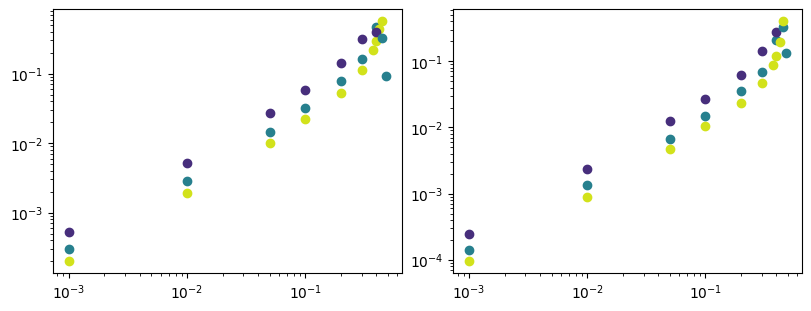

In [ ]:
p_rad = 0.5

nv_norm = plt.Normalize(0, 100)
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

for path in os.listdir('results'):
    data = np.load(os.path.join('results', path))
    
    _, nv, _, rad = path.split('.npz')[0].split('-')
    nv = int(nv)
    rad = float(rad)

    ax[0].scatter(p_rad - rad, np.mean(data['mu']), c=cmap(nv_norm(nv)))
    ax[1].scatter(p_rad - rad, np.std(data['mu']), c=cmap(nv_norm(nv)))

for a in ax:
    a.set_xscale('log')
    a.set_yscale('log')

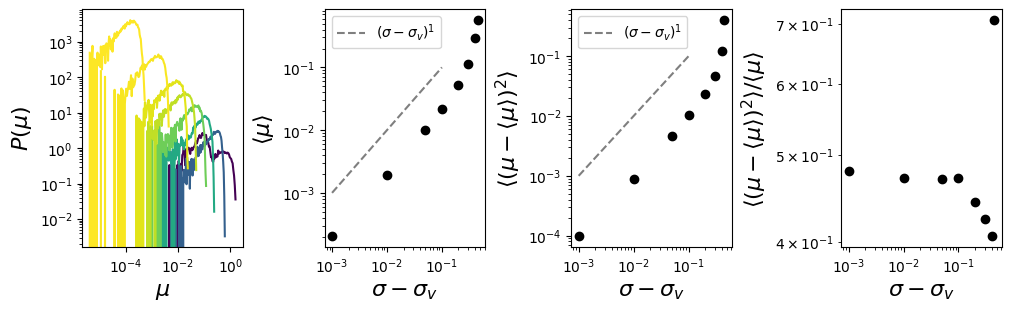

In [ ]:
p_rad = 0.5
# nv = 13
# nv = 43
nv = 93

paths = np.array([p if str(nv) in p else None for p in os.listdir('results')])
paths = paths[[p is not None for p in paths]]
rad = [float(p.split('.npz')[0].split('-')[-1]) for p in paths]
paths = np.array(paths)[np.argsort(rad)]
rad = np.sort(rad)

rad_norm = LogNorm(min(rad), max(rad))
cm = plt.cm.viridis

fig, ax = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)

for p, r in zip(paths, rad):
    data = np.load(os.path.join('results', p))
    
    mu = data['mu']

    mu_bins = np.logspace(
        np.log10(min(mu)),
        np.log10(max(mu)),
        int(np.sqrt(mu.size))
    )

    p_mu, mu_edge = np.histogram(
        mu,
        mu_bins,
        density=True
    )
    mu_ax = (mu_edge[1:] + mu_edge[:-1]) / 2

    ax[0].plot(mu_ax, p_mu, color=cm(rad_norm(r)))
    ax[1].scatter(p_rad - r, np.mean(mu), c='k')
    ax[2].scatter(p_rad - r, np.std(mu), c='k')
    ax[3].scatter(p_rad - r, np.std(mu) / np.mean(mu), c='k')

x = np.logspace(-3, -1)
ax[1].plot(x, x, color='k', ls='--', zorder=0, alpha=0.5, label=r'$(\sigma - \sigma_v)^1$')
ax[2].plot(x, x, color='k', ls='--', zorder=0, alpha=0.5, label=r'$(\sigma - \sigma_v)^1$')

for a in ax:
    a.set_xscale('log')
    a.set_yscale('log')
ax[0].set_xlabel(r'$\mu$', fontsize=16)
ax[0].set_ylabel(r'$P(\mu)$', fontsize=16)
for a in ax[1:]:
    a.set_xlabel(r'$\sigma - \sigma_v$', fontsize=16)
for a in ax[1:3]:
    a.legend()
ax[1].set_ylabel(r'$\langle \mu \rangle$', fontsize=16)
ax[2].set_ylabel(r'$\langle (\mu  - \langle \mu \rangle)^2 \rangle$', fontsize=16)
ax[3].set_ylabel(r'$\langle (\mu  - \langle \mu \rangle)^2 \rangle / \langle \mu \rangle$', fontsize=16)

plt.savefig(f'figures/results-{nv}.png', dpi=600)